In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Create project folder in Drive
import os
PROJECT_DIR = '/content/drive/MyDrive/PolicySentimentProject'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/results', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models', exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")

#Check GPU availability
import torch
if torch.cuda.is_available():
    print(f"GPU Available: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected!")
    print("Go to: Runtime → Change runtime type → GPU")

# Install required packages
!pip install -q transformers torch pandas numpy matplotlib seaborn
!pip install -q wordcloud plotly scipy scikit-learn
!pip install -q nltk spacy bertopic
!pip install -q newspaper3k tqdm
!python -m spacy download en_core_web_sm -q

print("\nAll packages installed successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/PolicySentimentProject
GPU Available: Tesla T4
GPU Memory: 15.6 GB
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 12.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 93.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 95.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to relo

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from collections import Counter
from datetime import datetime
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import spacy
from wordcloud import WordCloud
from transformers import pipeline

warnings.filterwarnings('ignore')
tqdm.pandas()

print("All imports successful!")

def save_checkpoint(df, step_name):
    """Save progress after each major step"""
    path = f'{PROJECT_DIR}/data/checkpoint_{step_name}.csv'
    df.to_csv(path, index=False)
    print(f"✅ Checkpoint saved: {path}")

def load_checkpoint(step_name):
    """Load progress if session crashed"""
    path = f'{PROJECT_DIR}/data/checkpoint_{step_name}.csv'
    if os.path.exists(path):
        print(f"📂 Loading checkpoint: {path}")
        return pd.read_csv(path)
    print(f"❌ No checkpoint found for: {step_name}")
    return None

All imports successful!


In [ ]:
import os
PROJECT_DIR = '/content/drive/MyDrive/PolicySentimentProject'

CSV_PATH = "/content/drive/MyDrive/PolicySentimentProject/data/News_sentiment_Jan2017_to_Apr2021.csv"

df_raw = pd.read_csv(CSV_PATH)
print(f"Raw dataset shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print(df_raw.head(3))

# Standardize columns
df = df_raw.copy()
df.columns = df.columns.str.strip()

# Parse dates
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Clean text
df['text'] = df['Title'].astype(str).str.strip()
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True)

# Remove short/empty headlines
df = df.dropna(subset=['Date', 'text'])
df = df[df['text'].str.len() > 30]

# Remove duplicates
df = df.drop_duplicates(subset=['Date', 'text'])

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

# Existing Flair sentiment (from dataset)
df['flair_compound'] = df['confidence'].astype(float)
flair_map = {'POSITIVE': 'positive', 'NEGATIVE': 'negative'}
df['flair_label'] = df['sentiment'].map(flair_map)

print(f"\nCleaned dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nSentiment distribution:")
print(df['flair_label'].value_counts())

save_checkpoint(df, 'step1_clean')

Raw dataset shape: (200500, 5)
Columns: ['Date', 'Title', 'URL', 'sentiment', 'confidence']
         Date                                              Title  \
0  05-01-2017  Eliminating shadow economy to have positive im...   
1  05-01-2017  Two Chinese companies hit roadblock with India...   
2  05-01-2017                SoftBank India Vision gets new $100   

                                                 URL sentiment  confidence  
0  http://economictimes.indiatimes.com/news/econo...  POSITIVE    0.996185  
1  http://economictimes.indiatimes.com/news/econo...  NEGATIVE   -0.955493  
2  http://economictimes.indiatimes.com/small-biz/...  POSITIVE    0.595612  

Cleaned dataset shape: (200437, 8)
Date range: 2017-01-01 00:00:00 to 2021-04-15 00:00:00

Sentiment distribution:
flair_label
negative    108080
positive     92357
Name: count, dtype: int64
✅ Checkpoint saved: /content/drive/MyDrive/PolicySentimentProject/data/checkpoint_step1_clean.csv


Total headlines: 200437
Policy-related headlines: 40423 (20.2%)

Topic distribution:
primary_topic
monetary_policy      9385
fiscal_budget        8193
trade_forex          7273
growth_employment    6948
tax_gst              3055
covid_economic       2246
inflation            2179
banking_credit       1144
Name: count, dtype: int64


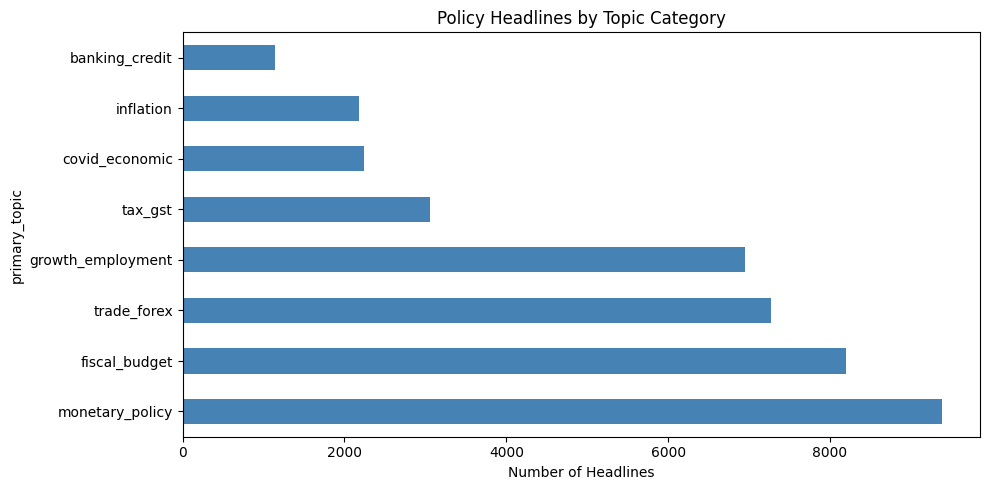

✅ Checkpoint saved: /content/drive/MyDrive/PolicySentimentProject/data/checkpoint_step2_filtered.csv


In [ ]:
POLICY_KEYWORDS = {
    # ---- MONETARY POLICY ----
    "monetary_policy": [
        r"\brbi\b", r"\breserve bank\b", r"\brepo rate\b", r"\breverse repo\b",
        r"\bcrr\b", r"\bslr\b", r"\bmonetary policy\b", r"\bmpc\b",
        r"\binterest rate\b", r"\brate cut\b", r"\brate hike\b",
        r"\bliquidity\b", r"\bopen market\b", r"\bbond yield\b",
        r"\baccommodative\b", r"\bhawkish\b", r"\bdovish\b",
        r"\bcash reserve\b", r"\bbank rate\b"
    ],

    # ---- INFLATION ----
    "inflation": [
        r"\binflation\b", r"\bcpi\b", r"\bwpi\b", r"\bconsumer price\b",
        r"\bwholesale price\b", r"\bprice rise\b", r"\bcost of living\b",
        r"\bfood price\b", r"\bfuel price\b", r"\bdeflation\b",
        r"\bprice hike\b", r"\bcommodity price\b"
    ],

    # ---- FISCAL POLICY & BUDGET ----
    "fiscal_budget": [
        r"\bbudget\b", r"\bfiscal deficit\b", r"\bfiscal policy\b",
        r"\bfinance minister\b", r"\bnirmala\b", r"\bjaitley\b",
        r"\bcapital expenditure\b", r"\bcapex\b", r"\brevenue deficit\b",
        r"\bsubsidy\b", r"\bdisinvestment\b", r"\bdivestment\b",
        r"\bpublic spending\b", r"\bgovernment spending\b",
        r"\bfinance ministry\b", r"\bfiscal stimulus\b"
    ],

    # ---- TAX & GST ----
    "tax_gst": [
        r"\bgst\b", r"\bgoods and services tax\b", r"\bgst council\b",
        r"\bincome tax\b", r"\bcorporate tax\b", r"\btax reform\b",
        r"\btax cut\b", r"\btax slab\b", r"\btax relief\b",
        r"\bcustoms duty\b", r"\bexcise duty\b", r"\bcess\b",
        r"\btax evasion\b", r"\btax compliance\b"
    ],

    # ---- TRADE & FOREX ----
    "trade_forex": [
        r"\bimport\b", r"\bexport\b", r"\btrade deficit\b",
        r"\btrade war\b", r"\btariff\b", r"\brupee\b",
        r"\bcurrent account\b", r"\bforeign exchange\b", r"\bforex\b",
        r"\bfdi\b", r"\bfii\b", r"\bforeign investment\b",
        r"\btrade policy\b", r"\bmake in india\b"
    ],

    # ---- BANKING & CREDIT ----
    "banking_credit": [
        r"\bnpa\b", r"\bbad loan\b", r"\bcredit growth\b",
        r"\bbank merger\b", r"\bpsu bank\b", r"\brecapitalization\b",
        r"\binsolvency\b", r"\bibc\b", r"\bnclt\b",
        r"\bmoratorium\b", r"\bloan restructuring\b",
        r"\bdigital payment\b", r"\bupi\b"
    ],

    # ---- EMPLOYMENT & GROWTH ----
    "growth_employment": [
        r"\bgdp\b", r"\bgrowth rate\b", r"\beconomic growth\b",
        r"\bunemployment\b", r"\bjob loss\b", r"\blayoff\b",
        r"\brecession\b", r"\bslowdown\b", r"\brecovery\b",
        r"\bmanufacturing\b", r"\bindustrial output\b",
        r"\biip\b", r"\bpmi\b"
    ],

    # ---- COVID ECONOMIC IMPACT ----
    "covid_economic": [
        r"\blockdown\b", r"\bstimulus\b", r"\brelief package\b",
        r"\batmanirbhar\b", r"\bcovid.*econom\b", r"\bpandemic.*econom\b",
        r"\beconom.*pandemic\b", r"\beconom.*lockdown\b"
    ]
}

# Compile regex patterns
topic_regex = {
    topic: re.compile("|".join(patterns), re.IGNORECASE)
    for topic, patterns in POLICY_KEYWORDS.items()
}

def detect_topics(text):
    """Detect all matching policy topics for a headline"""
    return [topic for topic, rx in topic_regex.items() if rx.search(text)]

df['policy_topics'] = df['text'].apply(detect_topics)
df['num_topics'] = df['policy_topics'].map(len)

# Filter only policy-related headlines
df_policy = df[df['num_topics'] > 0].copy()
df_policy['primary_topic'] = df_policy['policy_topics'].apply(lambda x: x[0])

print(f"Total headlines: {len(df)}")
print(f"Policy-related headlines: {len(df_policy)} ({len(df_policy)/len(df)*100:.1f}%)")
print(f"\nTopic distribution:")
topic_counts = df_policy['primary_topic'].value_counts()
print(topic_counts)

# Quick visualization
fig, ax = plt.subplots(figsize=(10, 5))
topic_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Policy Headlines by Topic Category')
ax.set_xlabel('Number of Headlines')
plt.tight_layout()
plt.show()

save_checkpoint(df_policy, 'step2_filtered')

Extracting entities (this may take a few minutes)...


100%|██████████| 40423/40423 [04:36<00:00, 146.10it/s]



Top 20 Most Mentioned Entities:
  RBI: 7203
  India: 4635
  US: 2467
  Rupee: 1622
  China: 1482
  Modi: 1465
  Arun Jaitley: 1198
  Nirmala Sitharaman: 831
  Budget: 612
  MPC: 500
  Fed: 490
  GST: 422
  Financial Express: 378
  Union Budget: 374
  Coronavirus: 345
  Shaktikanta Das: 326
  PMI: 309
  FDI: 302
  Finance Ministry: 296
  SBI: 270


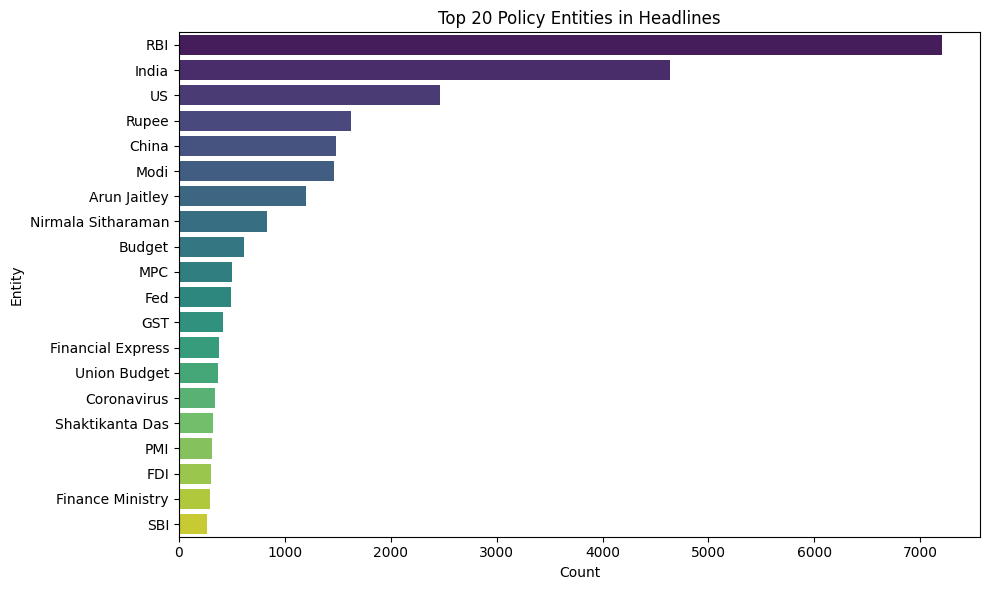

✅ Checkpoint saved: /content/drive/MyDrive/PolicySentimentProject/data/checkpoint_step3_entities.csv


In [ ]:
nlp = spacy.load("en_core_web_sm")

# Custom policy entities to look for
POLICY_ENTITIES = {
    "RBI": "Central Bank",
    "Reserve Bank": "Central Bank",
    "SEBI": "Regulator",
    "Finance Ministry": "Government",
    "GST Council": "Tax Authority",
    "MPC": "Monetary Committee",
    "NITI Aayog": "Policy Body",
    "Modi": "Political Leader",
    "Nirmala Sitharaman": "Finance Minister",
    "Arun Jaitley": "Finance Minister",
    "Raghuram Rajan": "RBI Governor",
    "Urjit Patel": "RBI Governor",
    "Shaktikanta Das": "RBI Governor"
}

def extract_entities(text):
    """Extract named entities using spaCy + custom matching"""
    doc = nlp(text)
    entities = []

    # spaCy NER
    for ent in doc.ents:
        if ent.label_ in ['ORG', 'PERSON', 'GPE']:
            entities.append(ent.text)

    # Custom entity matching
    text_lower = text.lower()
    for entity in POLICY_ENTITIES:
        if entity.lower() in text_lower:
            entities.append(entity)

    return list(set(entities))

# Apply to a sample first (full dataset takes time)
print("Extracting entities (this may take a few minutes)...")
df_policy['entities'] = df_policy['text'].progress_apply(extract_entities)

# Most mentioned entities
all_entities = [e for elist in df_policy['entities'] for e in elist]
entity_counts = Counter(all_entities).most_common(20)

print("\nTop 20 Most Mentioned Entities:")
for entity, count in entity_counts:
    print(f"  {entity}: {count}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
entities_df = pd.DataFrame(entity_counts, columns=['Entity', 'Count'])
sns.barplot(data=entities_df, y='Entity', x='Count', ax=ax, palette='viridis')
ax.set_title('Top 20 Policy Entities in Headlines')
plt.tight_layout()
plt.show()

save_checkpoint(df_policy, 'step3_entities')

In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

print(f"Running BERTopic on {len(df_policy)} policy headlines...")

# Use simple vectorizer to avoid noise from short headlines
vectorizer = CountVectorizer(
    stop_words='english',
    min_df=10,
    max_df=0.95,
    ngram_range=(1, 2)
)

# Initialize BERTopic with settings optimized for headlines
topic_model = BERTopic(
    vectorizer_model=vectorizer,
    nr_topics='auto',
    min_topic_size=50,
    verbose=True
)

# Fit on policy headlines
texts_for_topics = df_policy['text'].tolist()
topics, probs = topic_model.fit_transform(texts_for_topics)

# Add topic assignments to dataframe
df_policy['bert_topic_id'] = topics
df_policy['bert_topic_prob'] = probs

# View discovered topics
print("\n📊 Top 10 Discovered Topics:")
topic_info = topic_model.get_topic_info()
print(topic_info.head(10))

# Visualize top topics
fig_topics = topic_model.visualize_barchart(top_n_topics=10)
fig_topics.show()

# Topics over time
topics_over_time = topic_model.topics_over_time(
    texts_for_topics,
    df_policy['Date'].tolist()
)
fig_time = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=8)
fig_time.show()

# Save checkpoint
save_checkpoint(df_policy, 'step4_bertopic')
print("✅ BERTopic complete and saved!")

2026-03-21 08:53:05,073 - BERTopic - Embedding - Transforming documents to embeddings.


Running BERTopic on 40423 policy headlines...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Batches:   0%|          | 0/1264 [00:00<?, ?it/s]

2026-03-21 08:53:29,452 - BERTopic - Embedding - Completed ✓
2026-03-21 08:53:29,453 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-21 08:54:28,594 - BERTopic - Dimensionality - Completed ✓
2026-03-21 08:54:28,597 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-21 08:54:36,374 - BERTopic - Cluster - Completed ✓
2026-03-21 08:54:36,375 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-21 08:54:37,180 - BERTopic - Representation - Completed ✓
2026-03-21 08:54:37,181 - BERTopic - Topic reduction - Reducing number of topics
2026-03-21 08:54:37,230 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-21 08:54:38,038 - BERTopic - Representation - Completed ✓
2026-03-21 08:54:38,045 - BERTopic - Topic reduction - Reduced number of topics from 117 to 79



📊 Top 10 Discovered Topics:
   Topic  Count                                               Name  \
0     -1  11279                           -1_budget_rbi_growth_gdp   
1      0   3155                  0_rupee_dollar_opens_indian rupee   
2      1   2784            1_inflation_rbi_retail inflation_retail   
3      2   2601                   2_gst_council_tax_demonetisation   
4      3   1726                    3_coronavirus_covid_covid 19_19   
5      4   1080                 4_sensex_nifty_sensex nifty_points   
6      5    950                    5_arun jaitley_arun_jaitley_tax   
7      6    933              6_budget_budget 2019_2019_budget 2018   
8      7    801                        7_trade war_war_trade_china   
9      8    762  8_sitharaman_nirmala_nirmala sitharaman_fm nir...   

                                      Representation  \
0  [budget, rbi, growth, gdp, india, inflation, r...   
1  [rupee, dollar, opens, indian rupee, vs, 70, 6...   
2  [inflation, rbi, retail infla

2026-03-21 08:54:42,272 - BERTopic - WARNING: There are more than 100 unique timestamps (i.e., 1552) which significantly slows down the application. Consider setting `nr_bins` to a value lower than 100 to speed up calculation. 
1552it [00:28, 54.12it/s]


✅ Checkpoint saved: /content/drive/MyDrive/PolicySentimentProject/data/checkpoint_step4_bertopic.csv
✅ BERTopic complete and saved!


In [ ]:
from transformers import pipeline
import torch

# Check GPU
device = 0 if torch.cuda.is_available() else -1
print(f"Using: {'GPU ✅' if device == 0 else 'CPU ⚠️ (slower)'}")

# Load FinBERT
finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert",
    device=device
)

# Process in batches with progress tracking
BATCH_SIZE = 32
texts = df_policy['text'].str.slice(0, 512).tolist()
total = len(texts)

print(f"Processing {total} headlines with FinBERT...")

all_results = []
for i in tqdm(range(0, total, BATCH_SIZE), desc="FinBERT"):
    batch = texts[i:i + BATCH_SIZE]
    results = finbert(batch)
    all_results.extend(results)

# Extract labels and scores
df_policy['finbert_label'] = [r['label'].lower() for r in all_results]
df_policy['finbert_confidence'] = [r['score'] for r in all_results]

# Create compound score (-1 to +1)
label_map = {'positive': 1, 'neutral': 0, 'negative': -1}
df_policy['finbert_compound'] = (
    df_policy['finbert_label'].map(label_map) * df_policy['finbert_confidence']
)

# Quick summary
print("\n📊 FinBERT Sentiment Distribution:")
print(df_policy['finbert_label'].value_counts())
print(f"\nMean compound score: {df_policy['finbert_compound'].mean():.4f}")

# Save checkpoint (CRITICAL - this step takes time)
save_checkpoint(df_policy, 'step5_finbert')
print("✅ FinBERT complete and saved!")

Using: GPU ✅


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Processing 40423 headlines with FinBERT...



FinBERT:   1%|          | 10/1264 [00:05<07:40,  2.72it/s]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset

FinBERT: 100%|██████████| 1264/1264 [06:55<00:00,  3.04it/s]



📊 FinBERT Sentiment Distribution:
finbert_label
neutral     17319
negative    11715
positive    11389
Name: count, dtype: int64

Mean compound score: -0.0158
✅ Checkpoint saved: /content/drive/MyDrive/PolicySentimentProject/data/checkpoint_step5_finbert.csv
✅ FinBERT complete and saved!


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

print("Running VADER sentiment analysis...")

# VADER is fast - no batching needed
df_policy['vader_scores'] = df_policy['text'].progress_apply(
    lambda x: vader.polarity_scores(x)
)

# Extract compound score
df_policy['vader_compound'] = df_policy['vader_scores'].apply(
    lambda x: x['compound']
)

# Map to labels for comparison
def vader_label(compound):
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df_policy['vader_label'] = df_policy['vader_compound'].apply(vader_label)

# Clean up
df_policy = df_policy.drop(columns=['vader_scores'])

# Quick summary
print("\n📊 VADER Sentiment Distribution:")
print(df_policy['vader_label'].value_counts())
print(f"\nMean compound score: {df_policy['vader_compound'].mean():.4f}")

# Save checkpoint
save_checkpoint(df_policy, 'step6_vader')
print("✅ VADER complete and saved!")

Running VADER sentiment analysis...


100%|██████████| 40423/40423 [00:05<00:00, 7287.04it/s]



📊 VADER Sentiment Distribution:
vader_label
neutral     14350
positive    14064
negative    12009
Name: count, dtype: int64

Mean compound score: 0.0187
✅ Checkpoint saved: /content/drive/MyDrive/PolicySentimentProject/data/checkpoint_step6_vader.csv
✅ VADER complete and saved!


📊 Aspect-Based Sentiment Summary:
        aspect  avg_finbert  avg_vader  avg_flair  count
    gdp_growth    -0.025678   0.105055  -0.166327   6129
   rupee_forex    -0.072759  -0.020589  -0.680374   4913
     inflation    -0.019052  -0.006221  -0.582064   2861
           gst     0.013294   0.041748  -0.148138   2803
 interest_rate    -0.001978  -0.009576  -0.510053   2160
    employment    -0.338067  -0.246923  -0.553481    643
fiscal_deficit    -0.163272  -0.340926  -0.484434    495
   banking_npa    -0.110207  -0.168028  -0.376203    346


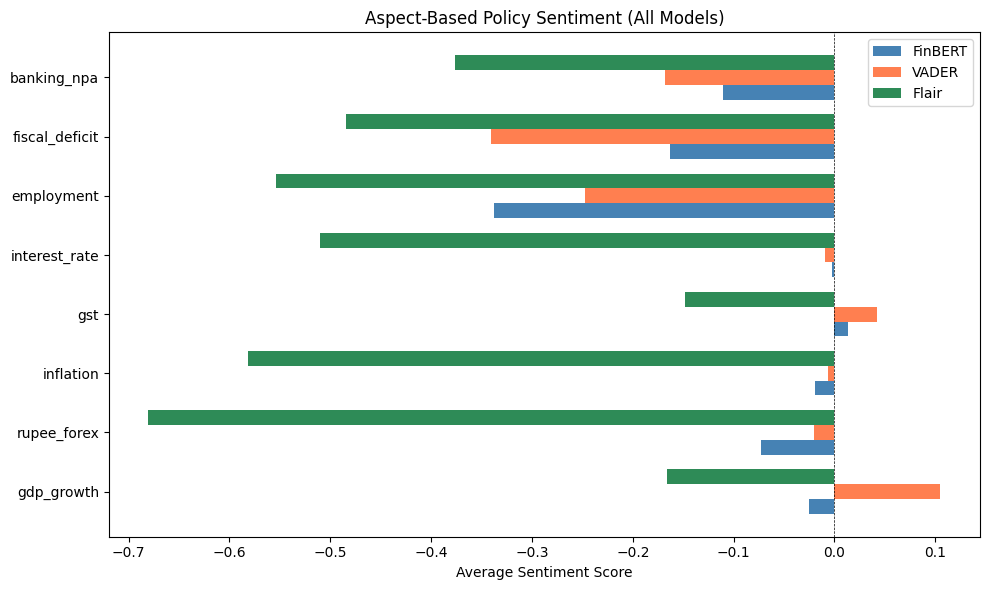

✅ Aspect-based sentiment complete!


In [ ]:
# Define key policy aspects to track sentiment for
POLICY_ASPECTS = {
    "inflation": [r"\binflation\b", r"\bcpi\b", r"\bwpi\b", r"\bprice rise\b", r"\bfood price\b"],
    "interest_rate": [r"\brepo rate\b", r"\binterest rate\b", r"\brate cut\b", r"\brate hike\b", r"\bmclr\b"],
    "gdp_growth": [r"\bgdp\b", r"\bgrowth rate\b", r"\beconomic growth\b", r"\bslowdown\b", r"\brecovery\b"],
    "fiscal_deficit": [r"\bfiscal deficit\b", r"\bbudget deficit\b", r"\bgovernment borrowing\b"],
    "rupee_forex": [r"\brupee\b", r"\bforex\b", r"\bdollar\b", r"\bcurrency\b", r"\bexchange rate\b"],
    "employment": [r"\bunemployment\b", r"\bjob\b", r"\blayoff\b", r"\bhiring\b", r"\bemployment\b"],
    "gst": [r"\bgst\b", r"\bgoods and services tax\b", r"\bgst council\b", r"\bgst rate\b"],
    "banking_npa": [r"\bnpa\b", r"\bbad loan\b", r"\bbank fraud\b", r"\bloan default\b"]
}

# Compile patterns
aspect_regex = {
    aspect: re.compile("|".join(patterns), re.IGNORECASE)
    for aspect, patterns in POLICY_ASPECTS.items()
}

# Detect aspects in each headline
def detect_aspects(text):
    return [aspect for aspect, rx in aspect_regex.items() if rx.search(text)]

df_policy['aspects'] = df_policy['text'].apply(detect_aspects)

# Create aspect-level sentiment dataframe
aspect_records = []
for _, row in df_policy.iterrows():
    for aspect in row['aspects']:
        aspect_records.append({
            'date': row['Date'],
            'aspect': aspect,
            'text': row['text'],
            'finbert_compound': row['finbert_compound'],
            'vader_compound': row['vader_compound'],
            'flair_compound': row['flair_compound']
        })

df_aspects = pd.DataFrame(aspect_records)

# Aspect-wise average sentiment
aspect_sentiment = (
    df_aspects
    .groupby('aspect')
    .agg(
        avg_finbert=('finbert_compound', 'mean'),
        avg_vader=('vader_compound', 'mean'),
        avg_flair=('flair_compound', 'mean'),
        count=('finbert_compound', 'size')
    )
    .sort_values('count', ascending=False)
    .reset_index()
)

print("📊 Aspect-Based Sentiment Summary:")
print(aspect_sentiment.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(aspect_sentiment))
width = 0.25

ax.barh([i - width for i in x], aspect_sentiment['avg_finbert'], width, label='FinBERT', color='steelblue')
ax.barh([i for i in x], aspect_sentiment['avg_vader'], width, label='VADER', color='coral')
ax.barh([i + width for i in x], aspect_sentiment['avg_flair'], width, label='Flair', color='seagreen')

ax.set_yticks(x)
ax.set_yticklabels(aspect_sentiment['aspect'])
ax.set_xlabel('Average Sentiment Score')
ax.set_title('Aspect-Based Policy Sentiment (All Models)')
ax.legend()
ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/aspect_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Aspect-based sentiment complete!")

In [ ]:
daily_sentiment = (
    df_policy
    .groupby(df_policy['Date'].dt.date)
    .agg(
        finbert_index=('finbert_compound', 'mean'),
        vader_index=('vader_compound', 'mean'),
        flair_index=('flair_compound', 'mean'),
        article_count=('finbert_compound', 'size'),
        pos_ratio=('finbert_label', lambda x: (x == 'positive').mean()),
        neg_ratio=('finbert_label', lambda x: (x == 'negative').mean()),
    )
    .reset_index()
    .rename(columns={'Date': 'date'})
    .sort_values('date')
)

# Convert date column
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])

# Rolling averages (smoothing)
for col in ['finbert_index', 'vader_index', 'flair_index']:
    daily_sentiment[f'{col}_7d'] = daily_sentiment[col].rolling(7, min_periods=1).mean()
    daily_sentiment[f'{col}_30d'] = daily_sentiment[col].rolling(30, min_periods=1).mean()

# Sentiment volatility (standard deviation over 14-day window)
daily_sentiment['sentiment_volatility'] = (
    daily_sentiment['finbert_index'].rolling(14, min_periods=3).std()
)

print("📊 Daily Sentiment Index (first 5 rows):")
print(daily_sentiment.head())
print(f"\nTotal trading days: {len(daily_sentiment)}")

# Topic-wise daily sentiment
topic_daily = (
    df_policy
    .groupby([df_policy['Date'].dt.date, 'primary_topic'])['finbert_compound']
    .mean()
    .reset_index()
    .pivot(index='Date', columns='primary_topic', values='finbert_compound')
    .sort_index()
)

save_checkpoint(daily_sentiment, 'step8_daily_index')
print("✅ Daily sentiment index constructed!")

📊 Daily Sentiment Index (first 5 rows):
        date  finbert_index  vader_index  flair_index  article_count  \
0 2017-01-01       0.182445     0.110350    -0.194424              8   
1 2017-01-02      -0.244518     0.091317    -0.212136             18   
2 2017-01-03       0.285290     0.099158    -0.282288             24   
3 2017-01-04       0.067780     0.055796    -0.041618             28   
4 2017-01-05      -0.021035     0.049504    -0.467968             26   

   pos_ratio  neg_ratio  finbert_index_7d  finbert_index_30d  vader_index_7d  \
0   0.375000   0.125000          0.182445           0.182445        0.110350   
1   0.166667   0.444444         -0.031036          -0.031036        0.100833   
2   0.500000   0.166667          0.074406           0.074406        0.100275   
3   0.285714   0.178571          0.072749           0.072749        0.089155   
4   0.230769   0.269231          0.053993           0.053993        0.081225   

   vader_index_30d  flair_index_7d  flair_inde

MODEL COMPARISON & VALIDATION

📊 1) CORRELATION BETWEEN MODELS
----------------------------------------
      Comparison  Pearson r Pearson p  Spearman r Spearman p
FinBERT vs Flair     0.3490  0.00e+00      0.4181   0.00e+00
FinBERT vs VADER     0.3810  0.00e+00      0.3720   0.00e+00
  VADER vs Flair     0.3118  0.00e+00      0.3448   0.00e+00

📊 2) POLARITY AGREEMENT (Do models agree on +/-?)
----------------------------------------
  FinBERT and Flair agree: 59.60%
  FinBERT and VADER agree: 72.87%
  VADER and Flair agree: 55.67%

FinBERT vs Flair Confusion Matrix:


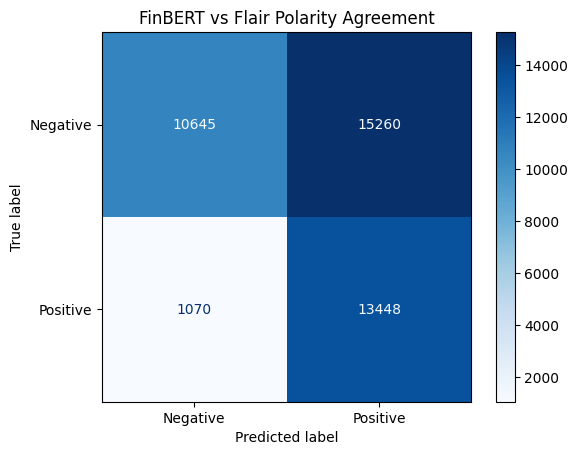

✅ Checkpoint saved: /content/drive/MyDrive/PolicySentimentProject/data/checkpoint_step7_model_comparison.csv
✅ Model comparison complete and saved!


In [ ]:
print("=" * 60)
print("MODEL COMPARISON & VALIDATION")
print("=" * 60)

# ----- 1) Correlation Analysis -----
print("\n📊 1) CORRELATION BETWEEN MODELS")
print("-" * 40)

models = {
    'FinBERT vs Flair': ('finbert_compound', 'flair_compound'),
    'FinBERT vs VADER': ('finbert_compound', 'vader_compound'),
    'VADER vs Flair': ('vader_compound', 'flair_compound')
}

correlation_results = []
for name, (col1, col2) in models.items():
    valid = df_policy.dropna(subset=[col1, col2])
    pearson_corr, pearson_p = pearsonr(valid[col1], valid[col2])
    spearman_corr, spearman_p = spearmanr(valid[col1], valid[col2])
    correlation_results.append({
        'Comparison': name,
        'Pearson r': round(pearson_corr, 4),
        'Pearson p': f"{pearson_p:.2e}",
        'Spearman r': round(spearman_corr, 4),
        'Spearman p': f"{spearman_p:.2e}"
    })

corr_df = pd.DataFrame(correlation_results)
print(corr_df.to_string(index=False))

# ----- 2) Polarity Agreement -----
print("\n📊 2) POLARITY AGREEMENT (Do models agree on +/-?)")
print("-" * 40)

# Convert all to binary polarity
df_policy['finbert_polarity'] = (df_policy['finbert_compound'] >= 0).astype(int)
df_policy['flair_polarity'] = (df_policy['flair_compound'] >= 0).astype(int)
df_policy['vader_polarity'] = (df_policy['vader_compound'] >= 0).astype(int)

# Calculate agreement
agreement_fb_flair = (df_policy['finbert_polarity'] == df_policy['flair_polarity']).mean()
agreement_fb_vader = (df_policy['finbert_polarity'] == df_policy['vader_polarity']).mean()
agreement_vader_flair = (df_policy['vader_polarity'] == df_policy['flair_polarity']).mean()

print(f"  FinBERT and Flair agree: {agreement_fb_flair:.2%}")
print(f"  FinBERT and VADER agree: {agreement_fb_vader:.2%}")
print(f"  VADER and Flair agree: {agreement_vader_flair:.2%}")

# Plot Confusion Matrix for FinBERT vs Flair (example)
print("\nFinBERT vs Flair Confusion Matrix:")
cm = confusion_matrix(df_policy['flair_polarity'], df_policy['finbert_polarity'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title('FinBERT vs Flair Polarity Agreement')
plt.show()

save_checkpoint(df_policy, 'step7_model_comparison')
print("✅ Model comparison complete and saved!")

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Map flair labels and finbert labels to same case & values
df_policy['flair_label_clean'] = df_policy['flair_label'].str.lower()
df_policy['finbert_label_clean'] = df_policy['finbert_label'].str.lower()

accuracy = accuracy_score(df_policy['flair_label_clean'], df_policy['finbert_label_clean'])
print(f"FinBERT accuracy against Flair labels: {accuracy:.4f}")

print("\nClassification report:\n", classification_report(df_policy['flair_label_clean'], df_policy['finbert_label_clean']))

FinBERT accuracy against Flair labels: 0.4016

Classification report:
               precision    recall  f1-score   support

    negative       0.91      0.41      0.57     25905
     neutral       0.00      0.00      0.00         0
    positive       0.49      0.38      0.43     14518

    accuracy                           0.40     40423
   macro avg       0.47      0.27      0.33     40423
weighted avg       0.76      0.40      0.52     40423



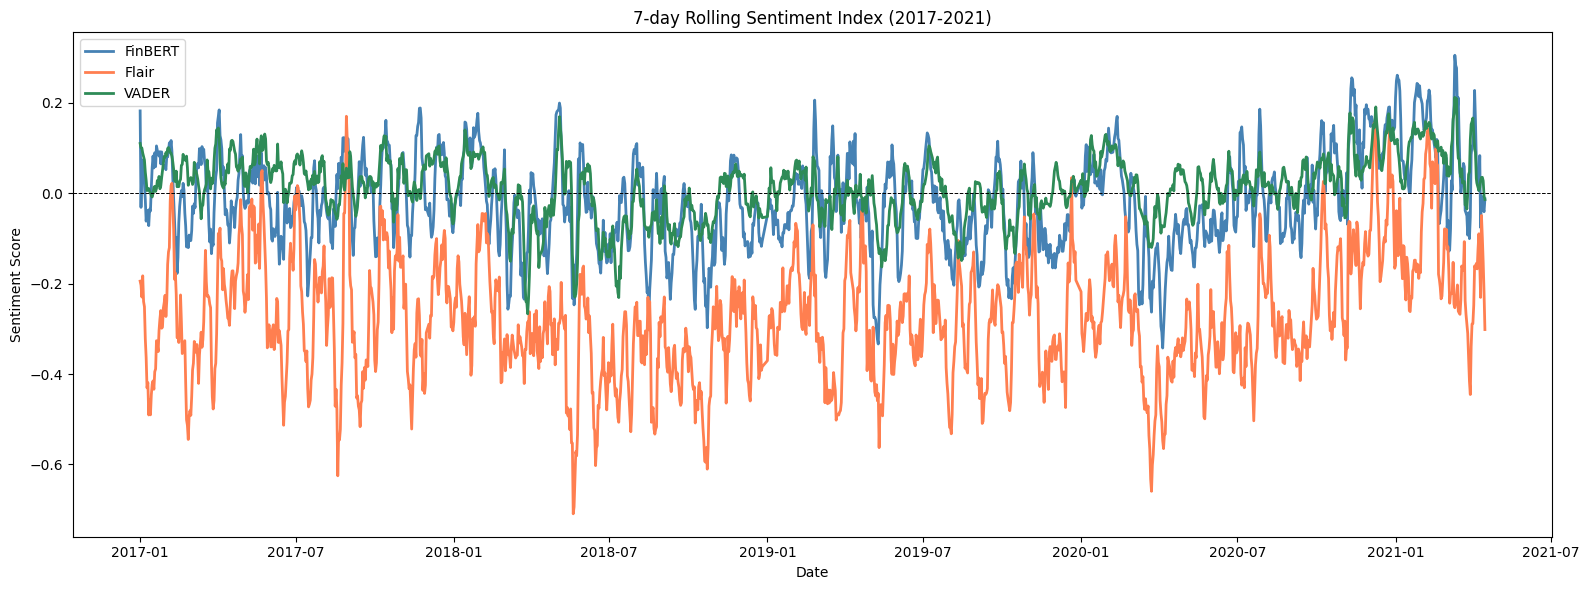

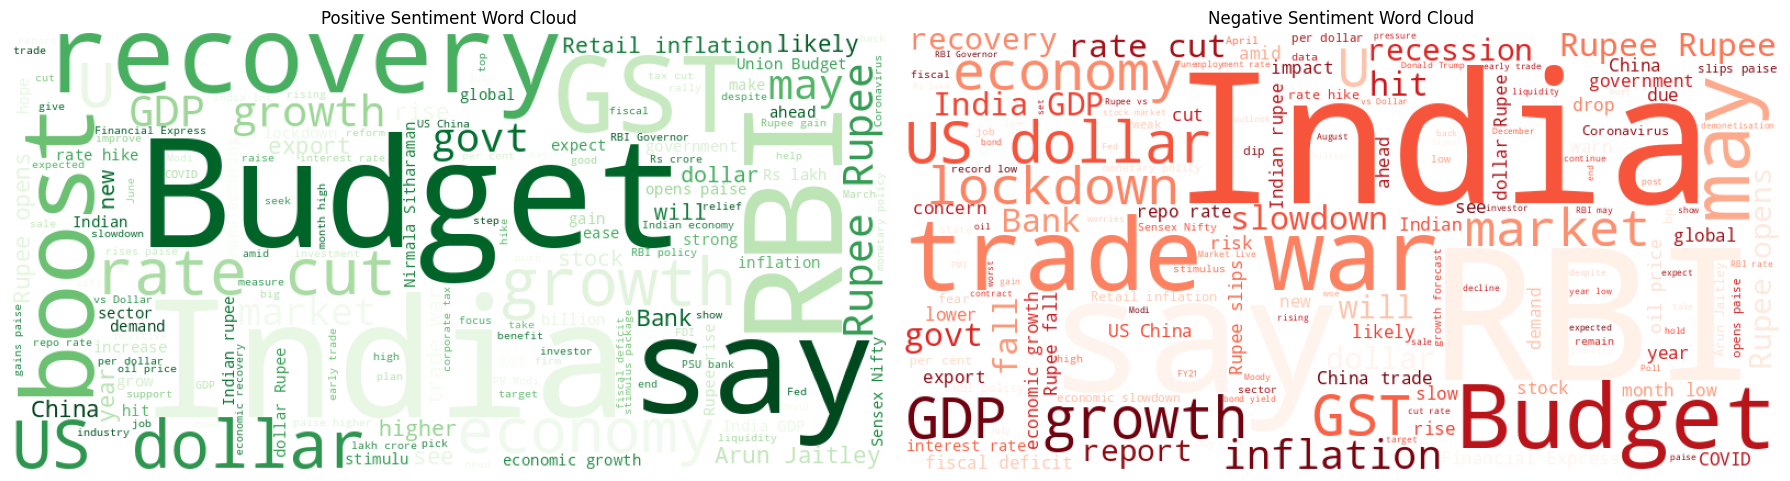

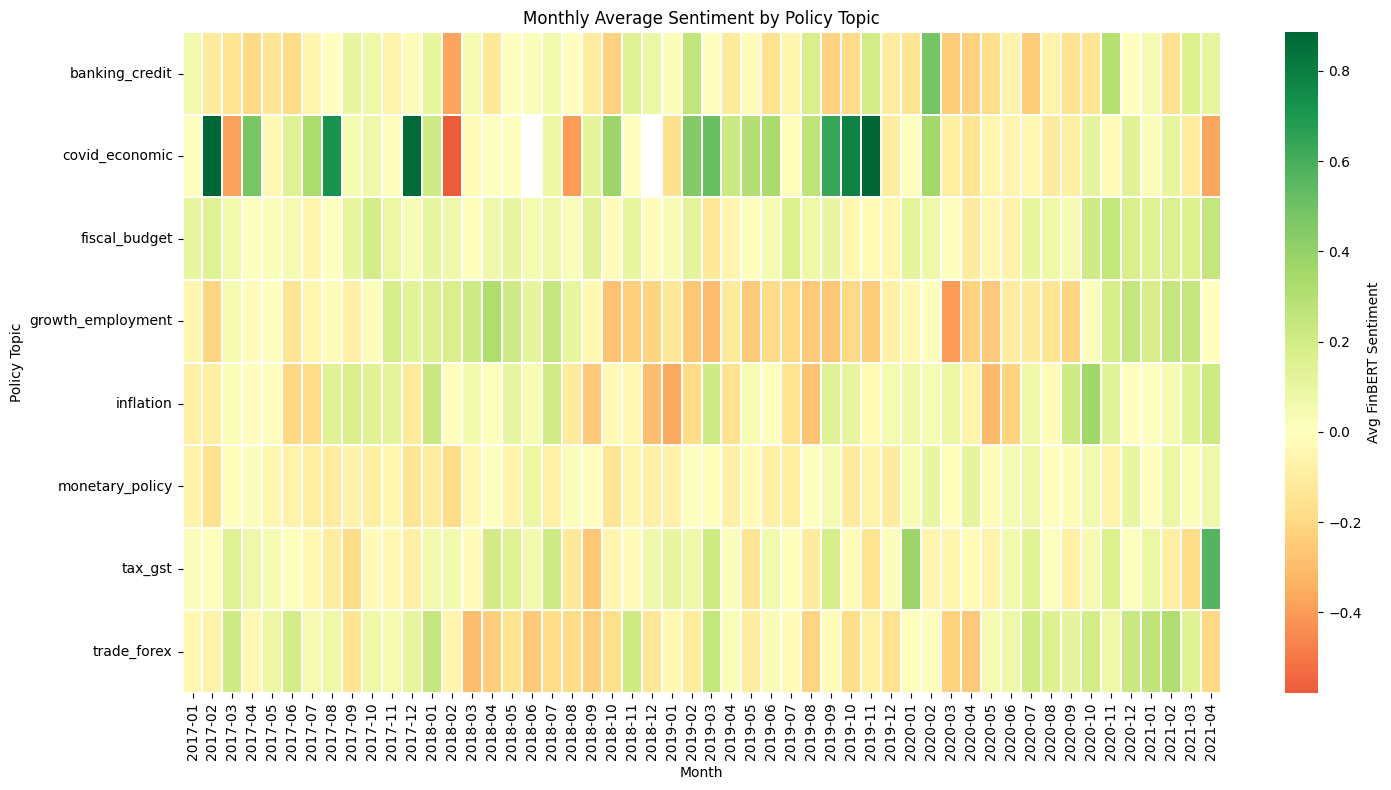

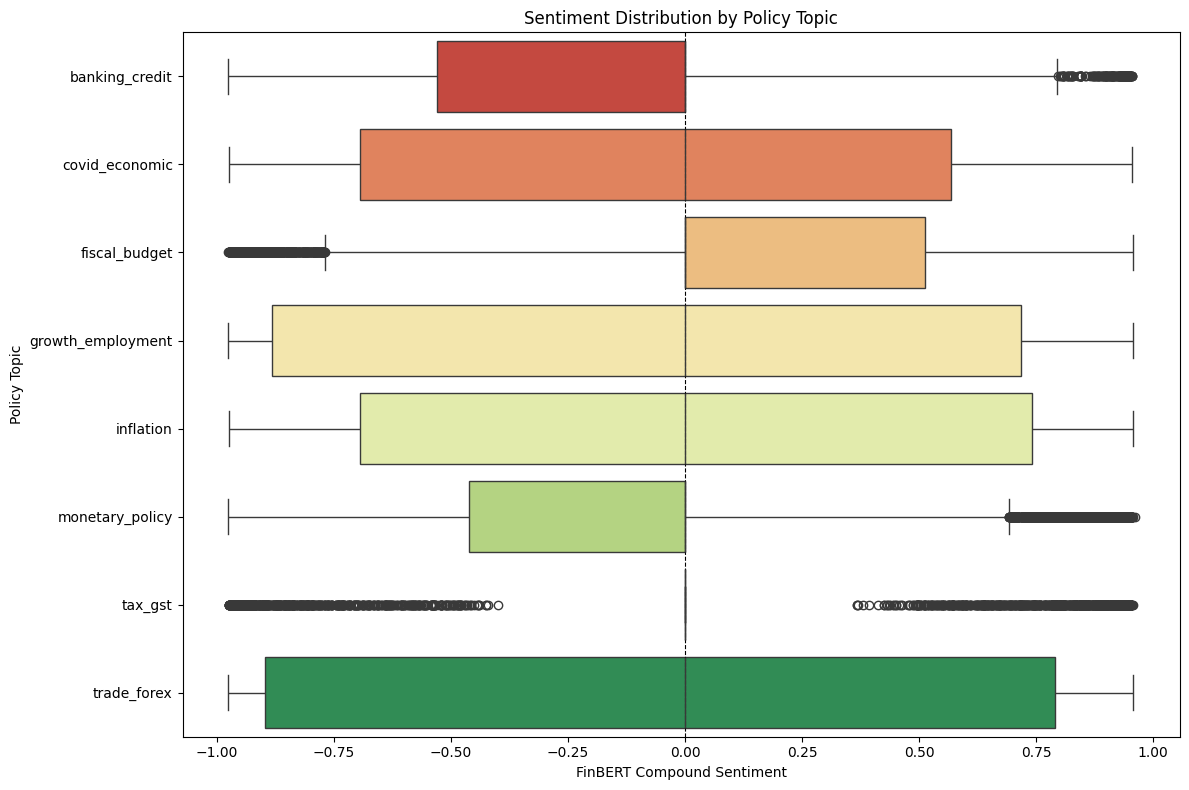

✅ All visualizations complete and saved.


In [ ]:
# SENTIMENT TIMELINE AND OTHER VISUALIZATIONS

import seaborn as sns
from wordcloud import WordCloud

# 1) Daily Sentiment Timeline
plt.figure(figsize=(16, 6))
plt.plot(daily_sentiment['date'], daily_sentiment['finbert_index_7d'], label='FinBERT', color='steelblue', linewidth=2)
plt.plot(daily_sentiment['date'], daily_sentiment['flair_index_7d'], label='Flair', color='coral', linewidth=2)
plt.plot(daily_sentiment['date'], daily_sentiment['vader_index_7d'], label='VADER', color='seagreen', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=0.7)
plt.title('7-day Rolling Sentiment Index (2017-2021)')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/sentiment_index_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

# 2) Word Clouds: Positive and Negative texts
positive_text = " ".join(df_policy[df_policy['finbert_compound'] > 0.3]['text'].tolist())
negative_text = " ".join(df_policy[df_policy['finbert_compound'] < -0.3]['text'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=150).generate(positive_text)
wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=150).generate(negative_text)

axes[0].imshow(wc_pos)
axes[0].set_title('Positive Sentiment Word Cloud')
axes[0].axis('off')

axes[1].imshow(wc_neg)
axes[1].set_title('Negative Sentiment Word Cloud')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()

# 3) Policy Topic Sentiment Heatmap (Monthly)
topic_monthly_sentiment = df_policy.copy()
topic_monthly_sentiment['month'] = topic_monthly_sentiment['Date'].dt.to_period('M')
topic_monthly = topic_monthly_sentiment.groupby(['month', 'primary_topic'])['finbert_compound'].mean().unstack()

plt.figure(figsize=(15, 8))
sns.heatmap(topic_monthly.T, cmap='RdYlGn', center=0, linewidths=0.3, cbar_kws={'label': 'Avg FinBERT Sentiment'})
plt.title('Monthly Average Sentiment by Policy Topic')
plt.xlabel('Month')
plt.ylabel('Policy Topic')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/topic_sentiment_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 4) Sentiment distribution by topic (boxplot)
plt.figure(figsize=(12, 8))
order = df_policy.groupby('primary_topic')['finbert_compound'].median().sort_values().index
sns.boxplot(data=df_policy, y='primary_topic', x='finbert_compound', order=order, palette='RdYlGn')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Sentiment Distribution by Policy Topic')
plt.xlabel('FinBERT Compound Sentiment')
plt.ylabel('Policy Topic')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/topic_sentiment_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ All visualizations complete and saved.")

### Observations from Heatmap:
- banking_credit and covid_economic show strong positive and negative fluctuations, reflecting economic uncertainty especially around COVID-19.
- fiscal_budget and monetary_policy sentiment is mostly neutral or slightly positive, with occasional drops possibly linked to policy events.
- trade_forex and inflation have more mixed sentiment, with visible months of negative sentiment, probably due to economic challenges.
- tax_gst shows slowly improving sentiment over time, possibly reflecting policy adaptations or public acceptance.
- growth_employment shows varied sentiment, indicating fluctuating optimism about jobs and economic growth.

### Observations from Box Plot
- trade_forex, inflation, growth_employment show predominantly
positive sentiment (boxes mostly right of zero), indicating generally optimistic news tone.
- tax_gst, monetary_policy, banking_credit are skewed toward negative sentiment (left side), suggesting concerns or criticism in these areas.
- covid_economic has a wide spread covering negative to moderately positive, showing mixed reactions possibly due to pandemic uncertainty.
- fiscal_budget appears near neutral/negative with some outliers, indicating divided public opinion on budget policies.

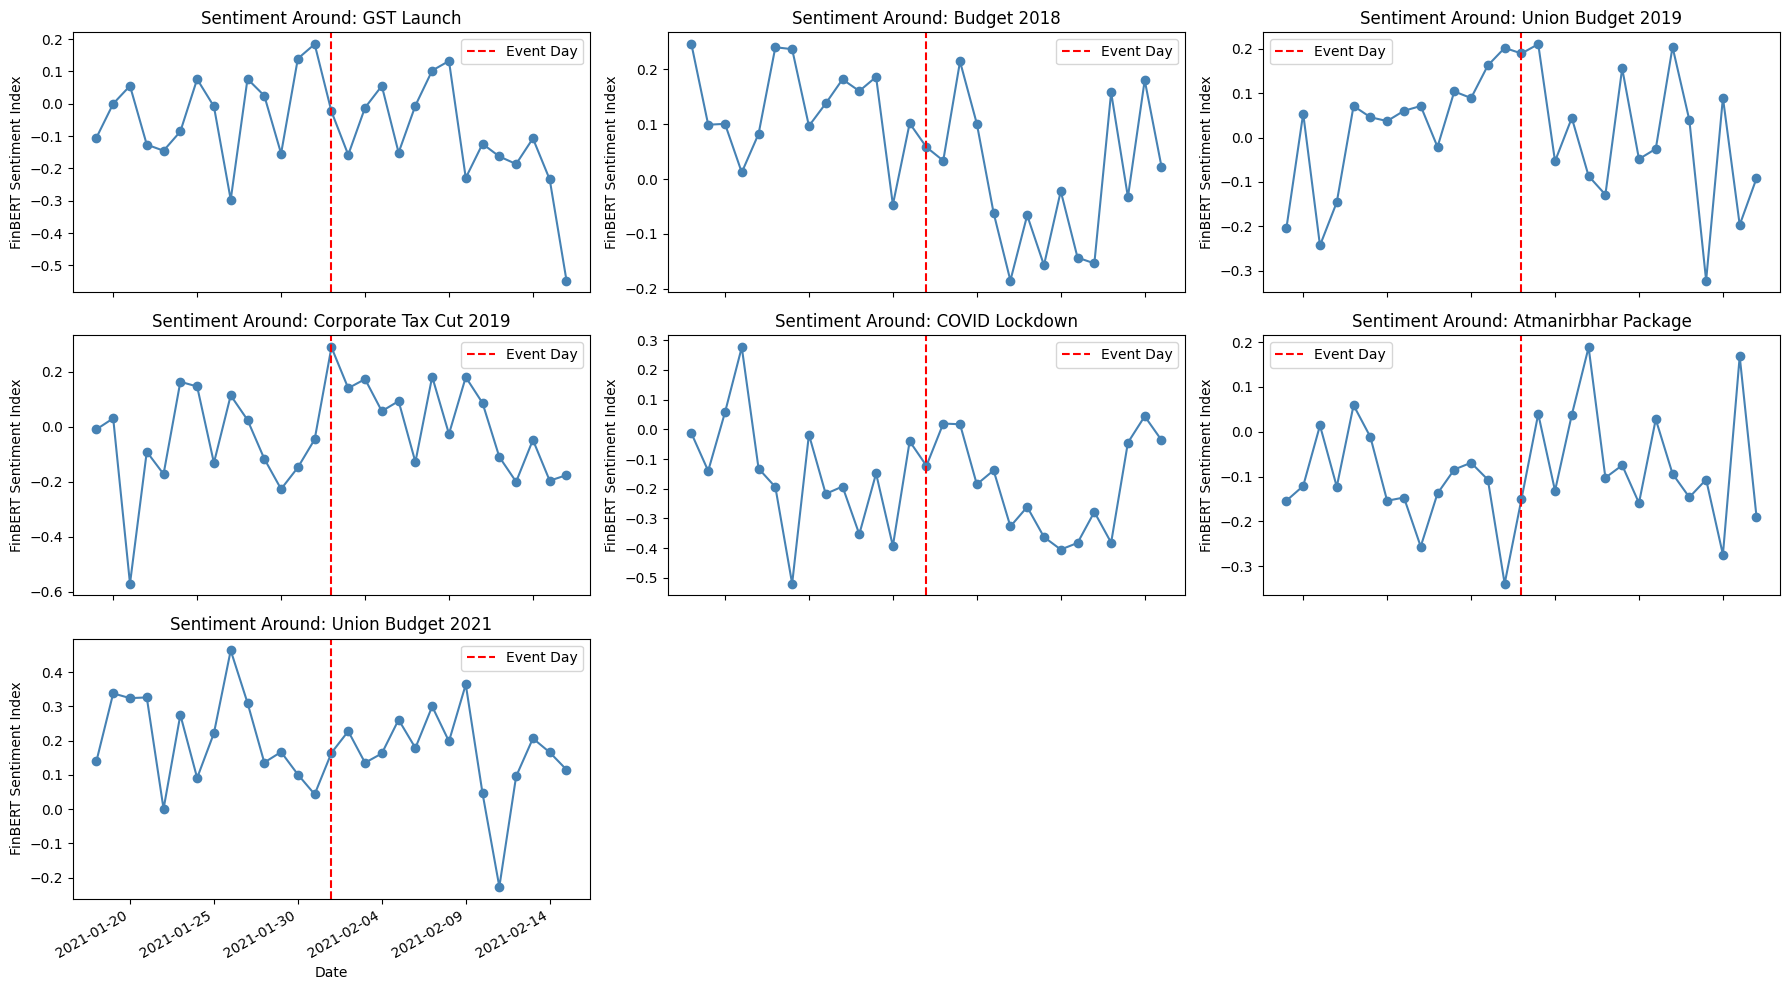

✅ Event study analysis complete and saved.


In [ ]:
# EVENT STUDY: SENTIMENT AROUND KEY POLICY ANNOUNCEMENTS

# Define important Indian economic policy event dates
policy_events = {
    'GST Launch': '2017-07-01',
    'Budget 2018': '2018-02-01',
    'Union Budget 2019': '2019-07-05',
    'Corporate Tax Cut 2019': '2019-09-20',
    'COVID Lockdown': '2020-03-25',
    'Atmanirbhar Package': '2020-05-12',
    'Union Budget 2021': '2021-02-01'
}

WINDOW_DAYS = 14  # days before and after event to consider

import matplotlib.dates as mdates
plt.figure(figsize=(18, 10))

for i, (event, date_str) in enumerate(policy_events.items()):
    event_date = pd.to_datetime(date_str)
    window = daily_sentiment[
        (daily_sentiment['date'] >= event_date - pd.Timedelta(days=WINDOW_DAYS)) &
        (daily_sentiment['date'] <= event_date + pd.Timedelta(days=WINDOW_DAYS))
    ]

    plt.subplot(3, 3, i+1)
    plt.plot(window['date'], window['finbert_index'], marker='o', color='steelblue')
    plt.axvline(event_date, color='red', linestyle='--', label='Event Day')
    plt.title(f'Sentiment Around: {event}')
    plt.xlabel('Date')
    plt.ylabel('FinBERT Sentiment Index')
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))
    plt.gcf().autofmt_xdate()
    plt.legend()

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/event_study_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Event study analysis complete and saved.")

Interpretation of Sentiment Trends Around Key Policy Events

The above plots show how public sentiment, measured by our FinBERT-based sentiment index, changed before and after important economic policy announcements in India. The red dashed vertical line marks the exact event day.

1. GST Launch:
Sentiment fluctuates modestly before the launch, indicating mixed expectations. Right after the event, we observe a slight dip, suggesting some initial concern or uncertainty among the public.

2. Budget 2018:
Before the budget announcement, sentiment is generally positive, reflecting optimism. Immediately following the event, sentiment drops notably, possibly expressing dissatisfaction or caution regarding the budget details.

3. Union Budget 2019:
Sentiment rises just before and after the budget day, indicating a generally positive reception and hopeful market expectations about this budget.

4. Corporate Tax Cut 2019:
Sentiment spikes positively on the day of the announcement, showing strong market enthusiasm for the tax relief. Sentiment remains mainly positive in the following days, demonstrating sustained approval.

5. COVID Lockdown:
Sentiment shows a clear negative trend after the lockdown announcement, reflecting widespread concern and uncertainty about the economic impact of the pandemic and restrictions.

6. Atmanirbhar Package:
Sentiment dips slightly on the announcement day, indicating initial skepticism or concerns about the stimulus package. However, subsequent days show mixed but less negative sentiment, hinting at cautious optimism.

7. Union Budget 2021:
Sentiment starts positive before the budget and remains generally positive after the announcement, suggesting a favorable reception and hope for economic recovery.

In [ ]:
# SAVE ALL FINAL DATA AND PLOTS

print("Saving all results and datasets to Google Drive...")

# Save full policy dataframe
df_policy.to_csv(f'{PROJECT_DIR}/data/policy_sentiment_complete.csv', index=False)

# Save daily sentiment index
daily_sentiment.to_csv(f'{PROJECT_DIR}/results/daily_sentiment_index.csv', index=False)

# Save policy topic monthly sentiment data (if exists)
try:
    topic_monthly.to_csv(f'{PROJECT_DIR}/results/topic_monthly_sentiment.csv')
except Exception:
    pass

# Save model comparison correlation data
try:
    corr_df.to_csv(f'{PROJECT_DIR}/results/model_correlation.csv', index=False)
except Exception:
    pass

print("✅ All results saved under:")
print(f"  Data: {PROJECT_DIR}/data/")
print(f"  Results: {PROJECT_DIR}/results/")

Saving all results and datasets to Google Drive...
✅ All results saved under:
  Data: /content/drive/MyDrive/PolicySentimentProject/data/
  Results: /content/drive/MyDrive/PolicySentimentProject/results/


In [ ]:
from transformers import pipeline
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Example:
new_headline = "RBI holds repo rate steady amid global economic uncertainties"

# Initialize FinBERT pipeline if not already loaded
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=0)  # set device=-1 if no GPU

# Initialize VADER if not already done
vader = SentimentIntensityAnalyzer()

# Function to get FinBERT sentiment compound score (-1 to +1)
def get_finbert_sentiment(text):
    result = finbert(text[:512])[0]  # truncate if long
    label_map = {'positive': 1, 'neutral': 0, 'negative': -1}
    return label_map[result['label'].lower()] * result['score']

# Function to get VADER sentiment compound score (-1 to +1)
def get_vader_sentiment(text):
    return vader.polarity_scores(text)['compound']

# Get sentiments
finbert_score = get_finbert_sentiment(new_headline)
vader_score = get_vader_sentiment(new_headline)
# flair_score = get_flair_sentiment(new_headline)  # uncomment if flair set up

print(f"Headline: {new_headline}")
print(f"FinBERT sentiment score: {finbert_score:.4f}")
print(f"VADER sentiment score: {vader_score:.4f}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Headline: RBI holds repo rate steady amid global economic uncertainties
FinBERT sentiment score: 0.4697
VADER sentiment score: -0.3400


###Headline Sentiment Scores
Headline:
“RBI holds repo rate steady amid global economic uncertainties”

**FinBERT sentiment score: +0.4697**

- This score is positive and moderately strong (~+0.47 on a scale from -1 to +1).
- It suggests that FinBERT interprets this headline’s tone as generally optimistic or neutral-to-positive, indicating steadiness in policy amidst uncertain times is viewed favorably.

**VADER sentiment score: -0.3400**

- VADER returns a negative score (~-0.34).
- VADER’s lexicon-based approach may interpret terms like “economic uncertainties” as negative and might weigh that more heavily than FinBERT does.

**What Does This Difference Tell Us?**
1. FinBERT, trained specifically on financial text, balances the positive meaning of “repo rate steady” (stability news) against uncertainty, leading to a positive overall score.
2. VADER, a general social media lexicon tool, flags “uncertainties” strongly as negative, pulling the overall score below zero.
- This difference highlights why domain-specific models like FinBERT are better suited for financial/economic news.
